# 04 — Baseline Recognition Model

## Project
**Identity-Preserving Synthetic Ocular Image Generation Using Conditional Diffusion Models**

## Dataset
**CASIA-Iris-Thousand**

---

## Introduction

This notebook establishes the baseline performance of an ocular recognition model using the original CASIA-Iris-Thousand dataset without any synthetic image augmentation.

The baseline is important because it provides a reference performance against which the following approaches will be compared later:

1. Baseline — Original images only
2. Traditional Augmentation — Original images with conventional data augmentation
3. GAN Augmentation — Original images supplemented with GAN-generated images
4. Diffusion Augmentation — Original images supplemented with diffusion-generated images

The recognition model will learn discriminative features from ocular images and use these features to identify the corresponding iris identity.

The dataset will be divided into training, validation, and testing sets. The test set will remain completely isolated from model training and augmentation experiments to prevent data leakage.

---

## Objectives

The main objectives of this notebook are:

- Load the CASIA-Iris-Thousand dataset.
- Identify the available subject/identity classes.
- Create appropriate training, validation, and test splits.
- Train a baseline ocular recognition model using only original images.
- Evaluate recognition performance on unseen test images.
- Record baseline performance metrics for comparison with later augmentation methods.

---

## Evaluation

The baseline model will be evaluated using recognition metrics such as:

- Accuracy
- Precision
- Recall
- F1-score

Additional biometric evaluation metrics such as FAR, FRR, EER, and ROC-AUC will be incorporated where appropriate in later stages of the project.

---

## Important Experimental Rule

No GAN-generated or diffusion-generated images will be used in this notebook.

This notebook represents the **original-data baseline** that will be used as the reference for all subsequent augmentation experiments.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
from pathlib import Path

# Main project folder
project_path = Path("/content/drive/MyDrive/Ocular_Project")

# CASIA-Iris-Thousand actual image folder
dataset_path = (
    project_path
    / "datasets"
    / "CASIA-Iris-Thousand"
    / "CASIA-Iris-Thousand"
    / "CASIA-Iris-Thousand"
)

# Train/validation/test split created in Notebook 02
split_csv_path = (
    project_path
    / "results"
    / "CASIA_Thousand_data_split.csv"
)

print("Dataset exists:", dataset_path.exists())
print("Split CSV exists:", split_csv_path.exists())

Dataset exists: True
Split CSV exists: True


In [4]:
import pandas as pd

# Load the train/validation/test split
split_df = pd.read_csv(split_csv_path)

print("Total images:", len(split_df))

print("\nColumns:")
print(split_df.columns.tolist())

print("\nSplit distribution:")
print(split_df["split"].value_counts())

print("\nFirst 5 rows:")
display(split_df.head())

Total images: 20000

Columns:
['image_path', 'identity', 'subject', 'eye', 'split']

Split distribution:
split
train         12000
validation     4000
test           4000
Name: count, dtype: int64

First 5 rows:


,image_path,identity,subject,eye,split
0,/content/drive/MyDrive/Ocular_Project/datasets...,000_L,0,L,train
1,/content/drive/MyDrive/Ocular_Project/datasets...,000_L,0,L,train
2,/content/drive/MyDrive/Ocular_Project/datasets...,000_L,0,L,train
3,/content/drive/MyDrive/Ocular_Project/datasets...,000_L,0,L,train
4,/content/drive/MyDrive/Ocular_Project/datasets...,000_L,0,L,train


In [5]:
# Check the number of unique eye identities

num_identities = split_df["identity"].nunique()

print("Number of unique eye identities:", num_identities)

print("\nImages per identity:")
print(split_df.groupby("identity").size().value_counts().sort_index())

Number of unique eye identities: 2000

Images per identity:
10    2000
Name: count, dtype: int64


In [6]:
# Check how many images each identity has in each split

identity_split_counts = (
    split_df
    .groupby(["identity", "split"])
    .size()
    .unstack(fill_value=0)
)

print(identity_split_counts.head(10))

print("\nUnique train counts:")
print(identity_split_counts["train"].value_counts())

print("\nUnique validation counts:")
print(identity_split_counts["validation"].value_counts())

print("\nUnique test counts:")
print(identity_split_counts["test"].value_counts())

split     test  train  validation
identity                         
000_L        2      6           2
000_R        2      6           2
001_L        2      6           2
001_R        2      6           2
002_L        2      6           2
002_R        2      6           2
003_L        2      6           2
003_R        2      6           2
004_L        2      6           2
004_R        2      6           2

Unique train counts:
train
6    2000
Name: count, dtype: int64

Unique validation counts:
validation
2    2000
Name: count, dtype: int64

Unique test counts:
test
2    2000
Name: count, dtype: int64


In [7]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [9]:
class OcularDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        # Get information about this image
        row = self.dataframe.iloc[index]

        image_path = row["image_path"]
        identity = row["identity"]

        # Load image as grayscale
        image = Image.open(image_path).convert("L")

        # Apply preprocessing / transformation
        if self.transform:
            image = self.transform(image)

        return image, identity

In [10]:
image_transform = transforms.Compose([
    transforms.CenterCrop(480),
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

print("Image transformation pipeline created.")

Image transformation pipeline created.


In [11]:
train_df = split_df[split_df["split"] == "train"].copy()
val_df = split_df[split_df["split"] == "validation"].copy()
test_df = split_df[split_df["split"] == "test"].copy()

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Training images: 12000
Validation images: 4000
Test images: 4000


In [12]:
train_dataset = OcularDataset(
    train_df,
    transform=image_transform
)

val_dataset = OcularDataset(
    val_df,
    transform=image_transform
)

test_dataset = OcularDataset(
    test_df,
    transform=image_transform
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 12000
Validation dataset: 4000
Test dataset: 4000


Identity: 000_L
Tensor shape: torch.Size([1, 256, 256])
Minimum pixel value: 0.0
Maximum pixel value: 0.9333333373069763


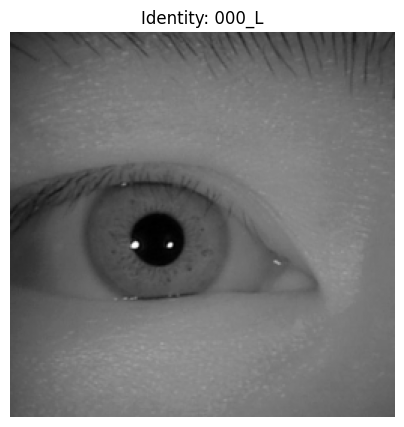

In [13]:
# Get one image from the training dataset
image, identity = train_dataset[0]

print("Identity:", identity)
print("Tensor shape:", image.shape)
print("Minimum pixel value:", image.min().item())
print("Maximum pixel value:", image.max().item())

# Display the image
plt.figure(figsize=(5, 5))
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Identity: {identity}")
plt.axis("off")
plt.show()

In [14]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 375
Validation batches: 125
Test batches: 125


In [15]:
# Get one batch from the training DataLoader
images, identities = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Number of identities in batch:", len(identities))

print("\nFirst 10 identities:")
print(identities[:10])

Image batch shape: torch.Size([32, 1, 256, 256])
Number of identities in batch: 32

First 10 identities:
('368_R', '849_R', '118_R', '639_L', '983_L', '850_L', '614_R', '596_L', '688_R', '325_R')


In [16]:
# Get all 2,000 unique eye identities
identities = sorted(split_df["identity"].unique())

# Map each identity to a numerical class label
identity_to_label = {
    identity: label
    for label, identity in enumerate(identities)
}

# Reverse mapping (useful later when interpreting predictions)
label_to_identity = {
    label: identity
    for identity, label in identity_to_label.items()
}

print("Number of classes:", len(identity_to_label))

print("\nFirst 10 mappings:")
for identity in identities[:10]:
    print(identity, "→", identity_to_label[identity])

print("\nLast mapping:")
print(identities[-1], "→", identity_to_label[identities[-1]])

Number of classes: 2000

First 10 mappings:
000_L → 0
000_R → 1
001_L → 2
001_R → 3
002_L → 4
002_R → 5
003_L → 6
003_R → 7
004_L → 8
004_R → 9

Last mapping:
999_R → 1999


In [17]:
class OcularDataset(Dataset):

    def __init__(self, dataframe, transform=None, identity_to_label=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.identity_to_label = identity_to_label

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["image_path"]
        identity = row["identity"]

        # Load image as grayscale
        image = Image.open(image_path).convert("L")

        # Apply transformations
        if self.transform:
            image = self.transform(image)

        # Convert identity name to numerical label
        label = self.identity_to_label[identity]

        return image, label

In [18]:
train_dataset = OcularDataset(
    train_df,
    transform=image_transform,
    identity_to_label=identity_to_label
)

val_dataset = OcularDataset(
    val_df,
    transform=image_transform,
    identity_to_label=identity_to_label
)

test_dataset = OcularDataset(
    test_df,
    transform=image_transform,
    identity_to_label=identity_to_label
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 12000
Validation dataset: 4000
Test dataset: 4000


In [19]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 375
Validation batches: 125
Test batches: 125


In [20]:
# Get one batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels shape:", labels.shape)
print("Label data type:", labels.dtype)

print("\nFirst 10 labels:")
print(labels[:10])

Image batch shape: torch.Size([32, 1, 256, 256])
Labels shape: torch.Size([32])
Label data type: torch.int64

First 10 labels:
tensor([ 774,  649, 1547, 1795, 1791,  922, 1818,  880,   60, 1299])


In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [22]:
# Load ResNet18
model = models.resnet18(weights=None)

# Change the first convolution layer
# because our images are grayscale (1 channel)
model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

# Change the final classification layer
# because we have 2,000 eye identities
model.fc = nn.Linear(
    model.fc.in_features,
    num_identities
)

# Move model to GPU
model = model.to(device)

print(model)

ResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [23]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss function: CrossEntropyLoss()
Optimizer: Adam


In [24]:
# Get one batch
images, labels = next(iter(train_loader))

# Move data to GPU
images = images.to(device)
labels = labels.to(device)

# Put model in training mode
model.train()

# Forward pass
outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Input shape: torch.Size([32, 1, 256, 256])
Output shape: torch.Size([32, 2000])
Labels shape: torch.Size([32])


In [25]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        # Move data to GPU
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [26]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    # No gradients needed during validation
    with torch.no_grad():

        for images, labels in loader:

            # Move data to GPU
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            # Forward pass
            outputs = model(images)

            # Calculate loss
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            total += labels.size(0)
            correct += (predictions == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [27]:
num_epochs = 10

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

print("Number of epochs:", num_epochs)

Number of epochs: 10


In [30]:
from pathlib import Path

datasets_folder = project_path / "datasets"

zip_files = list(datasets_folder.glob("*.zip"))

print("ZIP files found:")

for zip_file in zip_files:
    size_mb = zip_file.stat().st_size / (1024 ** 2)
    print(f"{zip_file.name}  →  {size_mb:.2f} MB")

ZIP files found:
archive.zip  →  490.79 MB


In [31]:
import shutil

local_dataset_root = Path("/content/CASIA-Iris-Thousand")

if local_dataset_root.exists():
    print("Removing incomplete local copy...")
    shutil.rmtree(local_dataset_root)
    print("Removed successfully.")
else:
    print("No incomplete local copy found.")

Removing incomplete local copy...
Removed successfully.


In [33]:
import shutil

zip_source = project_path / "datasets" / "archive.zip"
local_zip = Path("/content/CASIA-Iris-Thousand.zip")

print("Copying ZIP to Colab local storage...")

shutil.copy2(zip_source, local_zip)

print("ZIP copied successfully!")
print(f"Size: {local_zip.stat().st_size / (1024**2):.2f} MB")

Copying ZIP to Colab local storage...
ZIP copied successfully!
Size: 490.79 MB


In [34]:
import zipfile

local_dataset_root = Path("/content/CASIA-Iris-Thousand")

print("Extracting dataset...")

with zipfile.ZipFile(local_zip, "r") as zip_ref:
    zip_ref.extractall(local_dataset_root)

print("Dataset extracted successfully!")

Extracting dataset...
Dataset extracted successfully!


In [35]:
# Find directories containing the CASIA subject folders

for path in local_dataset_root.rglob("*"):
    if path.is_dir():
        subdirs = [p.name for p in path.iterdir() if p.is_dir()]

        # Look for a folder containing subject "000"
        if "000" in subdirs:
            print("Possible dataset folder:")
            print(path)

Possible dataset folder:
/content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand


In [36]:
# Local folder containing the 000–999 subject directories
local_image_root = (
    local_dataset_root
    / "CASIA-Iris-Thousand"
    / "CASIA-Iris-Thousand"
)

print("Local image folder exists:", local_image_root.exists())

# Replace Google Drive path with the corresponding local path
def get_local_path(identity, image_path):
    original_path = Path(image_path)

    # The image filename is the last part of the original path
    filename = original_path.name

    # Identity is like 000_L or 000_R
    subject = identity.split("_")[0]
    eye = identity.split("_")[1]

    return str(local_image_root / subject / eye / filename)

train_df["image_path"] = train_df.apply(
    lambda row: get_local_path(row["identity"], row["image_path"]),
    axis=1
)

val_df["image_path"] = val_df.apply(
    lambda row: get_local_path(row["identity"], row["image_path"]),
    axis=1
)

test_df["image_path"] = test_df.apply(
    lambda row: get_local_path(row["identity"], row["image_path"]),
    axis=1
)

print("Example local path:")
print(train_df.iloc[0]["image_path"])

Local image folder exists: True
Example local path:
/content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000/L/S5000L00.jpg


In [37]:
# Check whether the example image exists
example_path = train_df.iloc[0]["image_path"]

print("File exists:", Path(example_path).exists())
print("File path:", example_path)

# Try opening the image
test_image = Image.open(example_path)

print("Image size:", test_image.size)
print("Image mode:", test_image.mode)

File exists: True
File path: /content/CASIA-Iris-Thousand/CASIA-Iris-Thousand/CASIA-Iris-Thousand/000/L/S5000L00.jpg
Image size: (640, 480)
Image mode: L


In [38]:
train_dataset = OcularDataset(
    train_df,
    transform=image_transform,
    identity_to_label=identity_to_label
)

val_dataset = OcularDataset(
    val_df,
    transform=image_transform,
    identity_to_label=identity_to_label
)

test_dataset = OcularDataset(
    test_df,
    transform=image_transform,
    identity_to_label=identity_to_label
)

print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))

Train dataset: 12000
Validation dataset: 4000
Test dataset: 4000


In [39]:
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 375
Validation batches: 125
Test batches: 125


In [40]:
import time

model.train()

start_time = time.time()

for batch_idx, (images, labels) in enumerate(train_loader):

    images = images.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)

    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, labels)

    loss.backward()
    optimizer.step()

    if batch_idx == 9:
        break

elapsed_time = time.time() - start_time

print(f"Time for 10 batches: {elapsed_time:.2f} seconds")
print(f"Average time per batch: {elapsed_time / 10:.2f} seconds")
print(f"Estimated time for 1 epoch: {(elapsed_time / 10) * len(train_loader) / 60:.2f} minutes")

Time for 10 batches: 2.01 seconds
Average time per batch: 0.20 seconds
Estimated time for 1 epoch: 1.25 minutes


In [41]:
# Create a fresh ResNet18 model for the actual baseline experiment

model = models.resnet18(weights=None)

# Change first layer for grayscale images
model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=64,
    kernel_size=7,
    stride=2,
    padding=3,
    bias=False
)

# Change final layer for 2,000 eye identities
model.fc = nn.Linear(
    model.fc.in_features,
    num_identities
)

# Move model to GPU
model = model.to(device)

# Recreate the optimizer for the fresh model
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Fresh baseline model created.")
print("Number of classes:", num_identities)

Fresh baseline model created.
Number of classes: 2000


In [42]:
for epoch in range(num_epochs):

    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    print("-" * 40)

    # Train on 12,000 original training images
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Evaluate on 4,000 validation images
    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    # Store results
    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy * 100:.2f}%")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val Accuracy: {val_accuracy * 100:.2f}%")


Epoch 1/10
----------------------------------------
Train Loss: 7.6532
Train Accuracy: 0.02%
Val Loss: 7.5327
Val Accuracy: 0.10%

Epoch 2/10
----------------------------------------
Train Loss: 7.4279
Train Accuracy: 0.06%
Val Loss: 7.3889
Val Accuracy: 0.18%

Epoch 3/10
----------------------------------------
Train Loss: 7.0138
Train Accuracy: 0.25%
Val Loss: 6.8211
Val Accuracy: 0.83%

Epoch 4/10
----------------------------------------
Train Loss: 6.0892
Train Accuracy: 1.46%
Val Loss: 6.4451
Val Accuracy: 1.25%

Epoch 5/10
----------------------------------------
Train Loss: 5.1733
Train Accuracy: 5.22%
Val Loss: 6.4405
Val Accuracy: 2.95%

Epoch 6/10
----------------------------------------
Train Loss: 4.1794
Train Accuracy: 15.48%
Val Loss: 5.2955
Val Accuracy: 11.30%

Epoch 7/10
----------------------------------------
Train Loss: 2.8778
Train Accuracy: 36.78%
Val Loss: 4.9680
Val Accuracy: 18.75%

Epoch 8/10
----------------------------------------
Train Loss: 1.6780
Train A

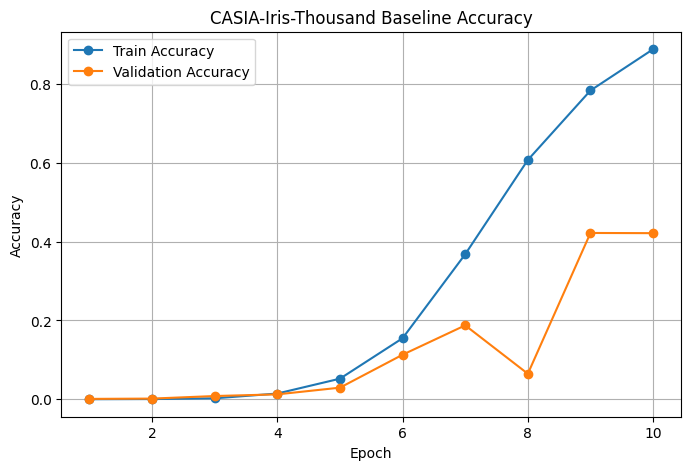

In [43]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, marker="o", label="Train Accuracy")
plt.plot(epochs, val_accuracies, marker="o", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CASIA-Iris-Thousand Baseline Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [44]:
import json
import torch

# Paths for saving baseline results
baseline_model_path = project_path / "models" / "CASIA_Thousand_baseline_resnet18.pth"
baseline_history_path = project_path / "results" / "CASIA_Thousand_baseline_training_history.json"

# Save model weights
torch.save(model.state_dict(), baseline_model_path)

# Save training history
history = {
    "epochs": list(range(1, num_epochs + 1)),
    "train_loss": [float(x) for x in train_losses],
    "train_accuracy": [float(x) for x in train_accuracies],
    "validation_loss": [float(x) for x in val_losses],
    "validation_accuracy": [float(x) for x in val_accuracies]
}

with open(baseline_history_path, "w") as f:
    json.dump(history, f, indent=4)

print("Baseline model saved to:")
print(baseline_model_path)

print("\nTraining history saved to:")
print(baseline_history_path)

print("\nFinal training accuracy:",
      f"{train_accuracies[-1] * 100:.2f}%")

print("Final validation accuracy:",
      f"{val_accuracies[-1] * 100:.2f}%")

Baseline model saved to:
/content/drive/MyDrive/Ocular_Project/models/CASIA_Thousand_baseline_resnet18.pth

Training history saved to:
/content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_baseline_training_history.json

Final training accuracy: 88.77%
Final validation accuracy: 42.12%


In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate_model(model, loader, device):
    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            predictions = outputs.argmax(dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_predictions)


# Evaluate on the untouched test set
test_labels, test_predictions = evaluate_model(
    model,
    test_loader,
    device
)

# Calculate metrics
test_accuracy = accuracy_score(test_labels, test_predictions)

test_precision = precision_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

print("Baseline Test Results")
print("-" * 30)
print(f"Accuracy : {test_accuracy * 100:.2f}%")
print(f"Precision: {test_precision * 100:.2f}%")
print(f"Recall   : {test_recall * 100:.2f}%")
print(f"F1-score : {test_f1 * 100:.2f}%")

Baseline Test Results
------------------------------
Accuracy : 30.18%
Precision: 27.24%
Recall   : 30.18%
F1-score : 26.07%


In [46]:
baseline_test_results = {
    "Dataset": "CASIA-Iris-Thousand",
    "Experiment": "Baseline",
    "Model": "ResNet18",
    "Training_Images": len(train_df),
    "Validation_Images": len(val_df),
    "Test_Images": len(test_df),
    "Number_of_Identities": num_identities,
    "Test_Accuracy": float(test_accuracy),
    "Test_Precision": float(test_precision),
    "Test_Recall": float(test_recall),
    "Test_F1": float(test_f1)
}

baseline_results_df = pd.DataFrame([baseline_test_results])

baseline_results_path = (
    project_path
    / "results"
    / "CASIA_Thousand_baseline_test_results.csv"
)

baseline_results_df.to_csv(
    baseline_results_path,
    index=False
)

display(baseline_results_df)

print("\nSaved to:")
print(baseline_results_path)

,Dataset,Experiment,Model,Training_Images,Validation_Images,Test_Images,Number_of_Identities,Test_Accuracy,Test_Precision,Test_Recall,Test_F1
0,CASIA-Iris-Thousand,Baseline,ResNet18,12000,4000,4000,2000,0.30175,0.272411,0.30175,0.260661



Saved to:
/content/drive/MyDrive/Ocular_Project/results/CASIA_Thousand_baseline_test_results.csv


# Baseline Experiment — Final Summary

## Dataset

**CASIA-Iris-Thousand**

- Total images: 20,000
- Eye identities: 2,000
- Images per eye identity: 10
- Training images: 12,000
- Validation images: 4,000
- Test images: 4,000

## Recognition Model

**ResNet18**

- Input: 256 × 256 grayscale images
- Input channels: 1
- Number of output classes: 2,000
- Training: 10 epochs
- Optimizer: Adam
- Learning rate: 0.001
- Loss function: Cross-Entropy Loss
- Hardware: NVIDIA Tesla T4 GPU

## Baseline Test Performance

| Metric | Result |
|---|---:|
| Accuracy | 30.18% |
| Precision | 27.24% |
| Recall | 30.18% |
| F1-score | 26.07% |

## Training Performance

- Final training accuracy: **88.77%**
- Final validation accuracy: **42.12%**

The baseline experiment establishes the recognition performance using only the original CASIA-Iris-Thousand training images, without synthetic augmentation.

This baseline will serve as the reference for the subsequent experiments involving:

1. Traditional data augmentation
2. GAN-based synthetic augmentation
3. Diffusion-based synthetic augmentation

The test set remains unchanged and will be used consistently for comparison across the augmentation experiments.